# Tripadvisor Reviews Analysis
### Authors: Erez, Hilla & Eitan
### Date: 2026-03

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [2]:
df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")
df.head()

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_10316\874356342.py:1: DtypeWarning: Columns (0: region) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")


,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


# Basic info

In [ ]:
df

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1083397 entries, 0 to 1083396
Data columns (total 42 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   restaurant_link                    1083397 non-null  str    
 1   restaurant_name                    1083396 non-null  str    
 2   original_location                  1083397 non-null  str    
 3   country                            1083397 non-null  str    
 4   region                             1033074 non-null  str    
 5   province                           742765 non-null   str    
 6   city                               682712 non-null   str    
 7   address                            1083397 non-null  str    
 8   latitude                           1067607 non-null  float64
 9   longitude                          1067607 non-null  float64
 10  claimed                            1081555 non-null  str    
 11  awards                             

,latitude,longitude,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere
count,1.067607e+06,1.067607e+06,593832.000000,593832.000000,593832.000000,986761.000000,1.031162e+06,988204.000000,988204.000000,988204.000000,988204.000000,988204.000000,988204.000000,599325.000000,604287.000000,602692.000000,261785.000000
mean,4.656718e+01,5.838040e+00,6.327081,62.023282,7.630754,4.035943,1.028890e+02,44.563415,24.653440,10.490516,4.109302,2.355306,2.954850,4.104179,4.067245,3.982897,3.933682
std,5.882611e+00,8.639410e+00,0.966734,30.538134,2.550128,0.713694,2.672415e+02,148.728179,89.850801,35.512256,15.669631,9.352756,11.030069,0.564208,0.581267,0.577605,0.555262
min,2.764031e+01,-7.121809e+01,1.000000,0.000000,1.000000,1.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,4.190986e+01,-8.027315e-01,6.000000,39.000000,6.000000,3.500000,6.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,3.500000,3.500000
50%,4.658510e+01,5.646530e+00,7.000000,58.500000,7.000000,4.000000,2.400000e+01,7.000000,3.000000,2.000000,1.000000,0.000000,0.000000,4.000000,4.000000,4.000000,4.000000
75%,5.140537e+01,1.223767e+01,7.000000,81.500000,7.000000,4.500000,9.300000e+01,26.000000,13.000000,6.000000,2.000000,1.000000,2.000000,4.500000,4.500000,4.500000,4.500000
max,6.994156e+01,3.336942e+01,7.000000,168.000000,15.000000,5.000000,5.240400e+04,15229.000000,9383.000000,4091.000000,2132.000000,1253.000000,1215.000000,5.000000,5.000000,5.000000,5.000000


### missing values

In [4]:
df.isnull().sum()

restaurant_link                           0
restaurant_name                           1
original_location                         0
country                                   0
region                                50323
province                             340632
city                                 400685
address                                   0
latitude                              15790
longitude                             15790
claimed                                1842
awards                               820264
popularity_detailed                   94988
popularity_generic                    97792
top_tags                             110634
price_level                          277205
price_range                          779070
meals                                448050
cuisines                             169103
special_diets                        743141
features                             765990
vegetarian_friendly                       0
vegan_options                   

### simple visualization

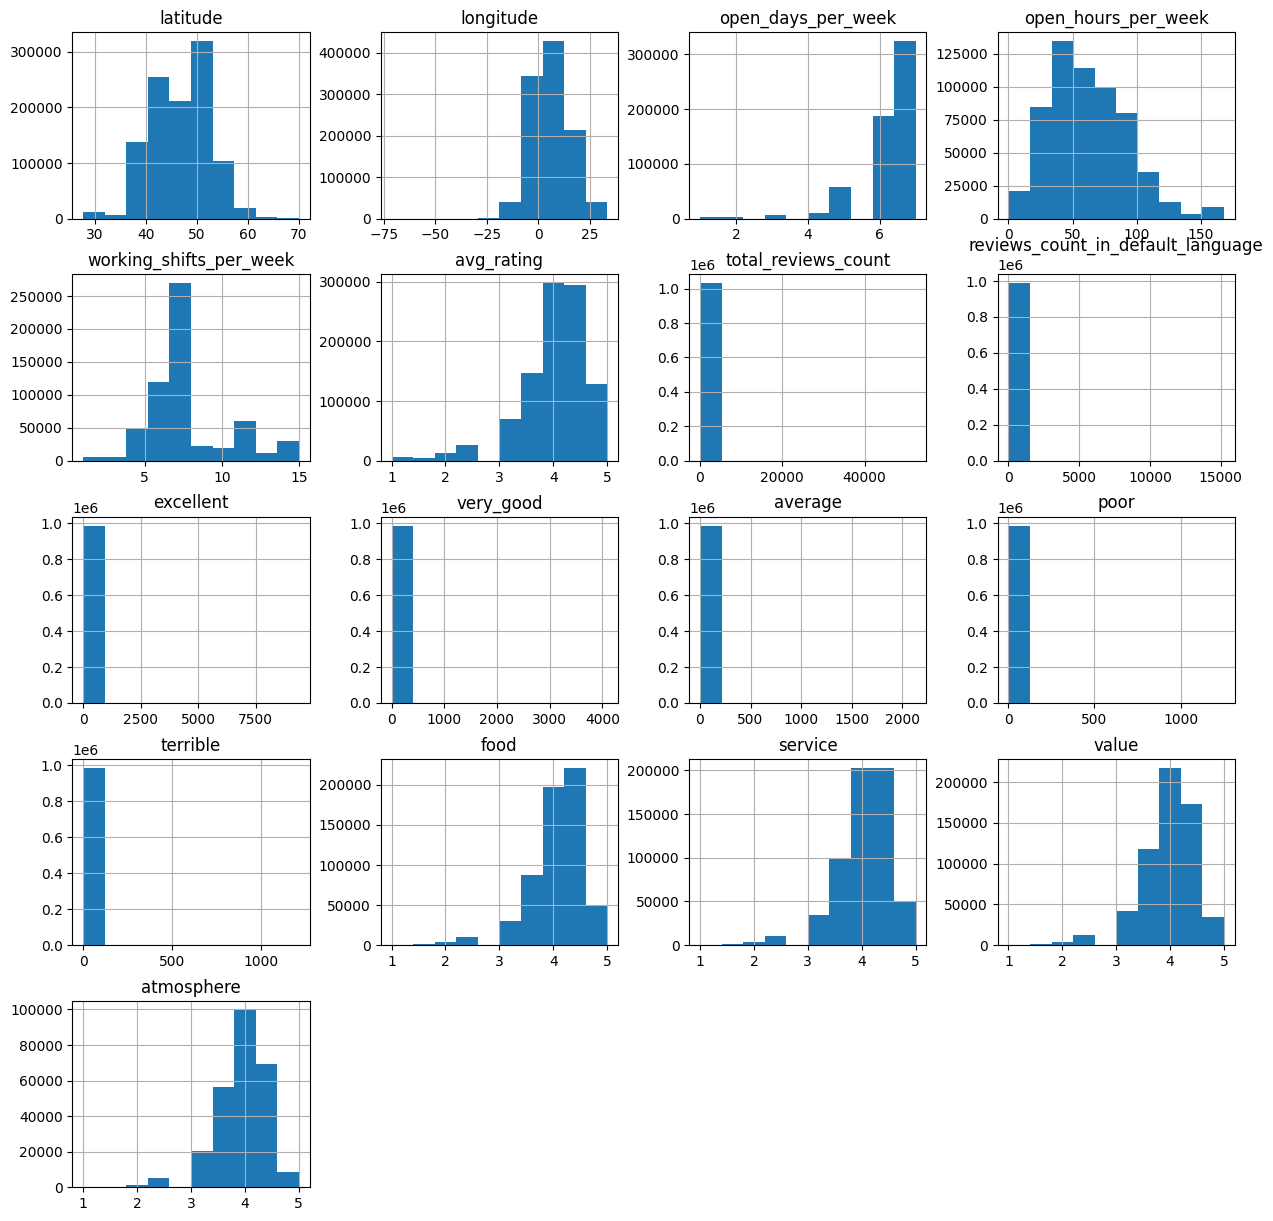

In [5]:
df.hist(figsize=(15, 15))
plt.show()

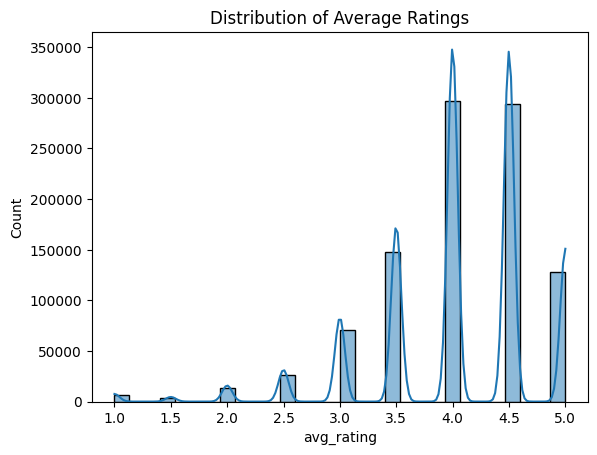

In [8]:
# Rating distribution
sns.histplot(df['avg_rating'], kde=True, bins=30)
plt.title('Distribution of Average Ratings')
plt.show()


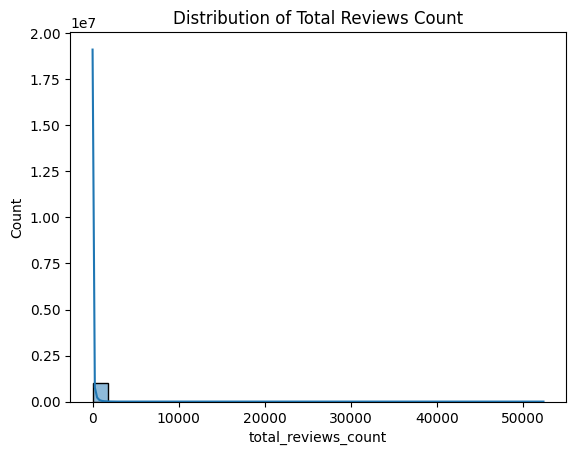

In [9]:

# Reviews count distribution
sns.histplot(df['total_reviews_count'], kde=True, bins=30)
plt.title('Distribution of Total Reviews Count')
plt.show()


In [16]:
print(df['price_range'].value_counts())

price_range
€10-€30     5937
€5-€15      5810
€10-€20     5148
€5-€20      4793
€10-€25     4448
            ... 
€1-€406        1
€7-€157        1
€2-€142        1
€18-€81        1
€35-€180       1
Name: count, Length: 7298, dtype: int64


In [23]:
# Step 1: Extract the lower bound from the price range (e.g., '€10-€30' → 10)
df['price_range_lower'] = df['price_range'].str.extract(r'€(\d+)').astype(float)

# Step 2: Create price categories based on the lower bound
def categorize_price(value):
    if value < 20:
        return 'Low'
    elif 20 <= value < 9000:
        return 'Medium'
    else:
        return 'High'

df['price_range_category'] = df['price_range_lower'].apply(categorize_price)

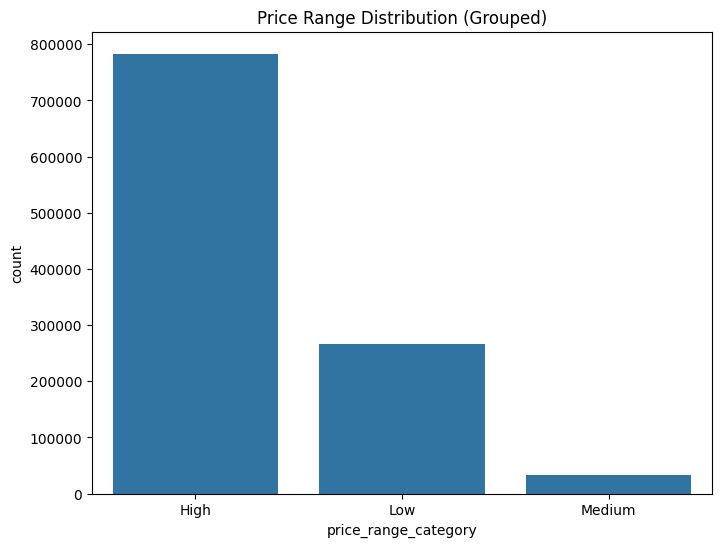

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(x='price_range_category', data=df)
plt.title('Price Range Distribution (Grouped)')
plt.show()

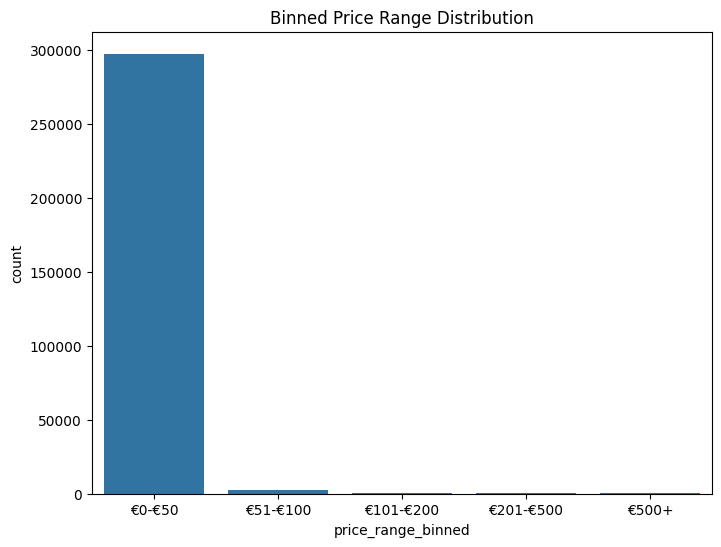

In [25]:
# Extract the lower bound of the price range as a float
df['price_range_lower'] = df['price_range'].str.extract(r'€(\d+)').astype(float)

# Define price bins (e.g., €0-€50, €51-€100, €101-€200, etc.)
bins = [0, 50, 100, 200, 500, 1000]
labels = ['€0-€50', '€51-€100', '€101-€200', '€201-€500', '€500+']

# Apply the bins to categorize the prices
df['price_range_binned'] = pd.cut(df['price_range_lower'], bins=bins, labels=labels, right=False)

# Plot the binned price ranges
plt.figure(figsize=(8, 6))
sns.countplot(x='price_range_binned', data=df)
plt.title('Binned Price Range Distribution')
plt.show()

country
Italy               224763
Spain               157479
France              155288
England             144681
Germany             115333
Greece               33763
Portugal             32592
The Netherlands      29792
Poland               24698
Belgium              23711
Austria              20487
Sweden               18555
Czech Republic       14844
Scotland             14215
Ireland              11203
Denmark               9485
Wales                 9134
Croatia               8375
Romania               7842
Hungary               7431
Finland               7372
Bulgaria              4469
Slovakia              4251
Northern Ireland      3634
Name: count, dtype: int64
cuisines
Italian           53243
French            39103
Cafe              35009
Spanish           27339
Italian, Pizza    26998
Name: count, dtype: int64


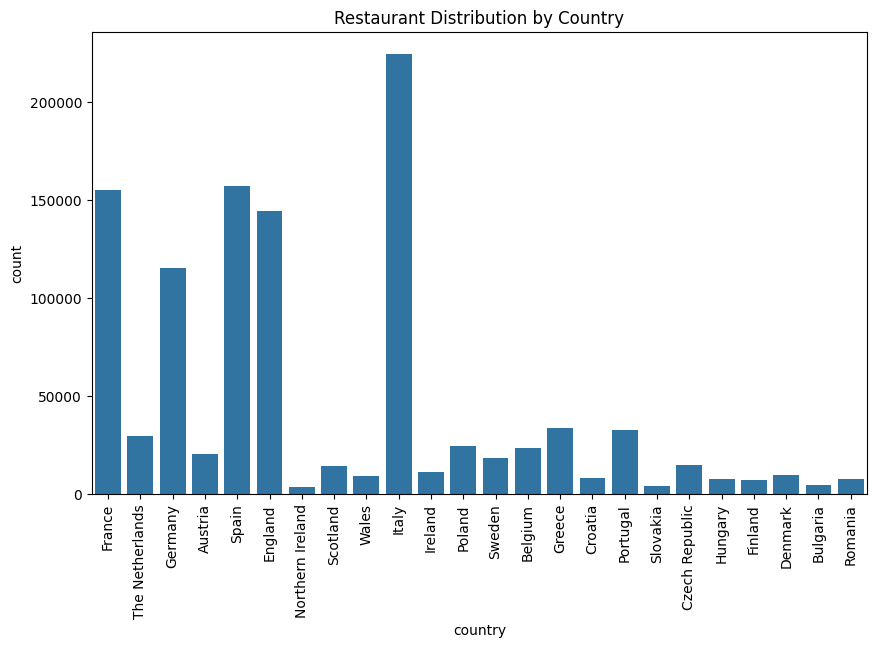

In [12]:
print(df['country'].value_counts())
print(df['cuisines'].value_counts().head())  # Check top cuisines

# Plot top countries
plt.figure(figsize=(10, 6))
sns.countplot(x='country', data=df)
plt.xticks(rotation=90)
plt.title('Restaurant Distribution by Country')
plt.show()

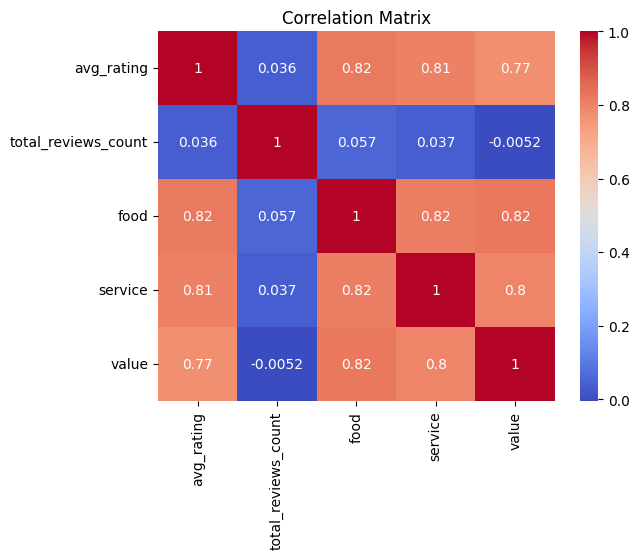

In [13]:
# Correlation heatmap
correlation_matrix = df[['avg_rating', 'total_reviews_count', 'food', 'service', 'value']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

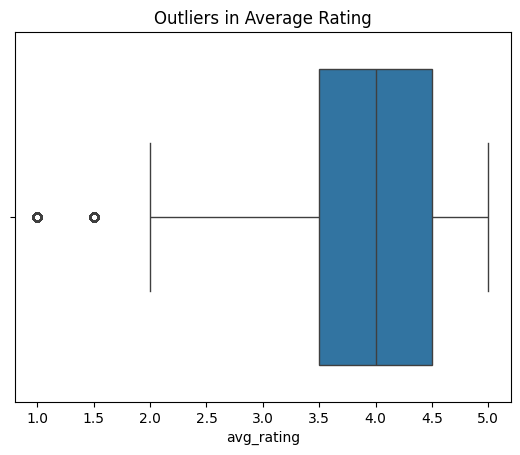

In [14]:
# Boxplot for outliers in ratings and review counts
sns.boxplot(x=df['avg_rating'])
plt.title('Outliers in Average Rating')
plt.show()

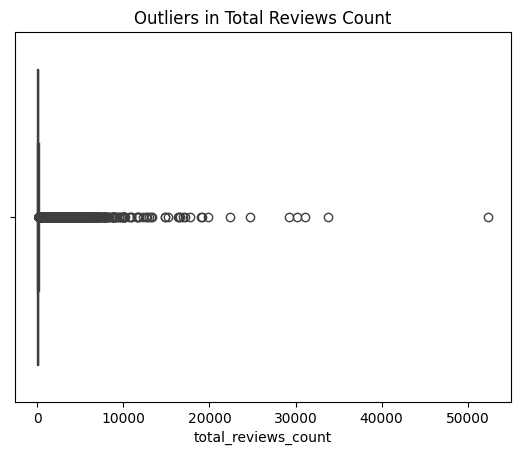

In [15]:
sns.boxplot(x=df['total_reviews_count'])
plt.title('Outliers in Total Reviews Count')
plt.show()